# **Multiple Linear Regression from Scratch to Scikit-Learn** 
$\hat{y} = f_{\vec{W},b} (\vec{X}) = w_1 x_1 + w_2 x_2 + w_3 x_3 + ... + w_n x_n + b = [w_1 w_2 w_3 ... w_n] [x_1 x_2 x_3 ... x_n] + b = \vec{W} . \vec{X} + b$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X = np.array([[1, 4, 1.5, 3.8],
              [3, 6, 1.0, 3.1],
              [4, 7, 0.8, 3.9],
              [5, 8, 0.4, 3.4],
              [7, 9, 0.2, 2.8]])
# W = [5, 10, -2, 0.5]; b = 2.0
y = np.array([45.9, 76.55, 92.35, 107.9, 128.0])

**Relationships of multiple features ($x_n$) with the target variable**

Text(0, 0.5, 'Salary (k)')

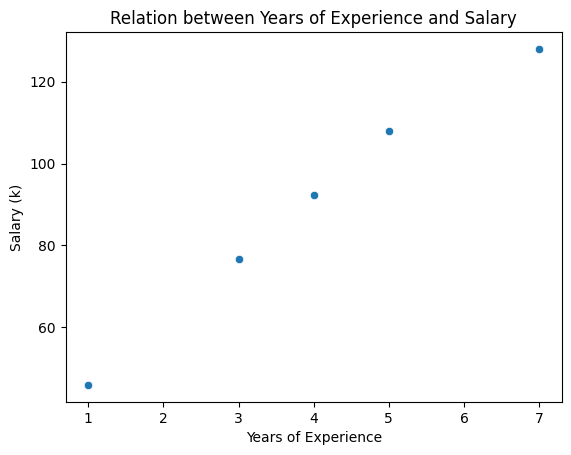

In [3]:
sns.scatterplot(x=X[:,0:1].ravel(), y=y) # X_1

plt.title("Relation between Years of Experience and Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")

Text(0, 0.5, 'Salary (k)')

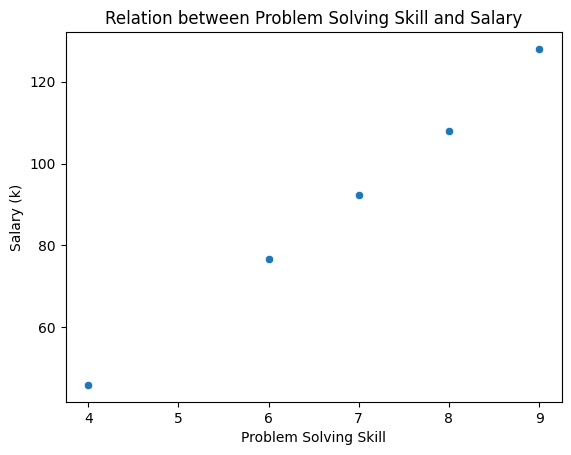

In [4]:
sns.scatterplot(x=X[:,1:2].ravel(), y=y)

plt.title("Relation between Problem Solving Skill and Salary")
plt.xlabel("Problem Solving Skill")
plt.ylabel("Salary (k)")

Text(0, 0.5, 'Salary (k)')

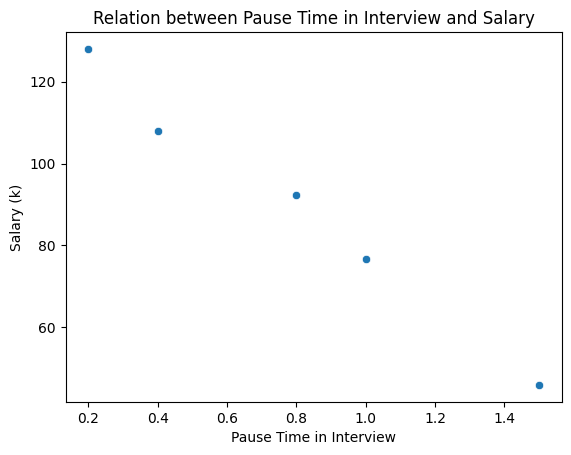

In [5]:
sns.scatterplot(x=X[:,2:3].ravel(), y=y)

plt.title("Relation between Pause Time in Interview and Salary")
plt.xlabel("Pause Time in Interview")
plt.ylabel("Salary (k)")

Text(0, 0.5, 'Salary (k)')

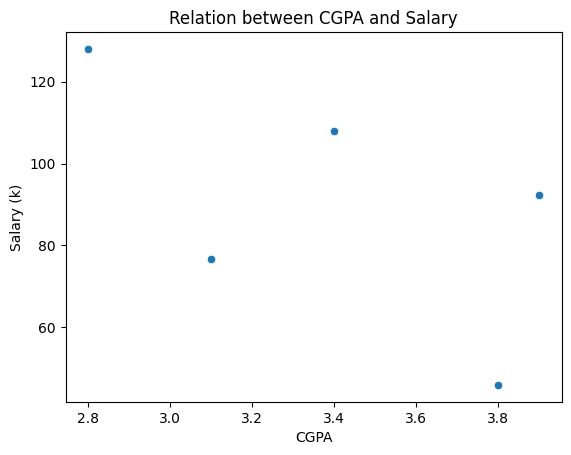

In [6]:
sns.scatterplot(x=X[:,3:].ravel(), y=y)

plt.title("Relation between CGPA and Salary")
plt.xlabel("CGPA")
plt.ylabel("Salary (k)")

---

### **Impleting the function [$\hat{y} = f_{\vec{W},b}(\vec{X}) = \vec{W} . \vec{X}+b$] using NumPy**

In [7]:
def make_prediction(X, W, b):
    m = X.shape[0]
    pred_list = np.zeros((m,))

    for i in range(m):
        pred_list[i] = np.dot(W,X[i]) + b

    return pred_list

In [8]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n,))
b_init = 1.0

make_prediction(X, W=W_init, b=b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

---

### **Cost Function Formulization and Implementation**
#### Cost, $J(\vec{W},b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y_i} - y_i)^2$

In [9]:
def compute_cost(X, y, W, b):
    m = X.shape[0]
    
    predictions = make_prediction(X, W, b)

    error_sq = (predictions - y)**2
    cost = np.sum(error_sq)/(2*m)

    return cost    

In [10]:
compute_cost(X, y, W=W_init, b=b_init)

np.float64(3060.2095)

### **Calculating Gradient and Optimizing Cost by Implementing Gradient Descent**
Gradient Descent:\
&emsp; $w_n = w_{n_{old}} - \alpha . \frac{\partial J}{\partial w_n}$\
&emsp; $b = b_{old} - \alpha . \frac{\partial J}{\partial b}$

Gradient:\
&emsp; $\frac{\partial J}{\partial w_n} = \frac{1}{m} \sum_{i=1}^{m}[(\hat{y_i}-y_i) . x_n^i$]; &emsp; [$x_n^i$ is equivalent to $X[i-1,n-1]$ in NumPy, $i$ indicating the row and $n$  the column]\
&emsp; $\frac {\partial J(w,b)} {\partial b} = \frac {1}{m} . \sum_{i=1}^{m} (\hat{y}-y)$

In [11]:
def calculate_gradient(X, y, W, b):
    m = X.shape[0] # number of rows or datapoints
    n = X.shape[1] # number of columns or features

    dj_dw = np.zeros((n,))
    dj_db = 0.0

    for i in range(m):
        prediction = np.dot(W, X[i]) + b 
        error = prediction - y[i]

        for j in range(n):
            dj_dw[j] += (error * X[i,j])
        
        dj_db += error

    return dj_dw/m, dj_db/m


In [12]:
W_init = np.ones((n,))
b_init = 1.0

calculate_gradient(X, y, W=W_init, b=b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

Gradient Descent:\
&emsp; $w_n = w_{n_{old}} - \alpha . \frac{\partial J}{\partial w_n}$\
&emsp; $b = b_{old} - \alpha . \frac{\partial J}{\partial b}$


In [13]:
def gradient_descent(X, y, W_input, b_input, max_iter, alpha):
    W = W_input
    b = b_input
    
    cost_memo = []
    iteration = []

    for i in range(max_iter+1):
        dj_dw, dj_db = calculate_gradient(X, y, W=W, b=b)

        W = W - (alpha * dj_dw) # no loop needed to calculate w through each input feature as numpy array works in parallel way
        b = b - (alpha * dj_db)

        cost_memo.append(compute_cost(X, y, W, b))
        iteration.append(i)

        if i%100 == 0:
            print(f"iteration: {i}; cost: {compute_cost(X, y, W, b)}; dj_dw: {dj_dw}; dj_db: {dj_db}; W: {W}, b: {b}")

    return W, b, cost_memo, iteration

In [14]:
W_init = np.zeros((X.shape[1],))
b_init = 0.0

W_final, b_final, cost_memo, iteration = gradient_descent(X, y, W_input=W_init, b_input=b_init, max_iter=300000, alpha=0.01)

iteration: 0; cost: 188.44576292554956; dj_dw: [-416.09  -660.91   -57.608 -299.43 ]; dj_db: -90.14; W: [4.1609  6.6091  0.57608 2.9943 ], b: 0.9014
iteration: 100; cost: 0.19774090504579225; dj_dw: [-0.28972633 -0.05290958  0.24653403  0.43027154]; dj_db: 0.08612436152810546; W: [ 6.8215041   8.3071171  -0.38008643  1.775159  ], b: 0.7104119585178922
iteration: 200; cost: 0.13030306911576753; dj_dw: [ 0.02982799 -0.05138487  0.04097921  0.06083368]; dj_db: 0.007027042739051126; W: [ 6.88604616  8.35924356 -0.48209566  1.60468101], b: 0.6799481624811825
iteration: 300; cost: 0.1229042426315661; dj_dw: [ 0.05097646 -0.04994653  0.0258774   0.03389236]; dj_db: 0.001434162447482379; W: [ 6.84103994  8.40989801 -0.51257454  1.56262078], b: 0.676854243885598
iteration: 400; cost: 0.11619104616813407; dj_dw: [ 0.05111217 -0.04855146  0.02422668  0.0311383 ]; dj_db: 0.0010265453320016603; W: [ 6.7896808   8.45913669 -0.53741432  1.53048588], b: 0.675704127006025
iteration: 500; cost: 0.109846

In [15]:
print(W_final)
print(b_final)

[ 4.98279664 10.09322445 -1.71615443  0.48529908]
1.263313081537703


---

# **Implementation through Scikit-Learn**

**LinearRegression Class** (For small to medium-sized datasets where an exact mathematical solution is quickly needed)

In [16]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
weights = model1.coef_
bias = model1.intercept_

print(weights)
print(bias)

[ 5.  10.  -2.   0.5]
2.000000000000142


**SGDRegressor Class** (when dealing with massive datasets (>10,000+ samples), streaming data, or high-dimensional features where computing the exact solution becomes too slow or memory-intensive)

In [18]:
from sklearn.linear_model import SGDRegressor

model2 = SGDRegressor(penalty=None, max_iter=100000000, learning_rate="constant")
model2.fit(X,y)

weights = model2.coef_
bias = model2.intercept_

print(weights)
print(bias)

[ 5.98695684  9.10360192 -1.14747401  1.30278352]
[0.52563232]


---
---